In [1]:
# Run garbage collection
import gc
gc.collect()

0

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import logging
import wfdb
import ast
import torch
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, confusion_matrix
from tabulate import tabulate
import os
from collections import Counter

In [3]:
file_log = './log/ptb_xl_dataset_analyze.log'
# Basic config: logs to a file
logging.basicConfig(
    filename=file_log,
    level=logging.INFO,       # Make sure the level is INFO or lower
    format='%(asctime)s - %(levelname)s - %(message)s', force=True
)
logging.info("----BEGIN PTB_XL dataset------")

# Show all rows without truncation
pd.set_option('display.max_rows', None)

# If you also want to prevent truncation horizontally (for wide content):
pd.set_option('display.max_colwidth', None)  # Or a large number

Available folds: [ 3  2  5  4  7  9 10  8  6  1]
Number of folds: 10
---------[Dataset] Total superclass--------
diagnostic_superclass
[NORM]                 9069
[MI]                   2532
[STTC]                 2400
[CD]                   1708
[MI, CD]               1297
[HYP, STTC]             781
[STTC, MI]              599
[HYP]                   535
[STTC, CD]              471
[]                      411
[NORM, CD]              407
[HYP, STTC, MI]         361
[HYP, CD]               300
[STTC, MI, CD]          223
[HYP, STTC, CD]         211
[HYP, MI]               183
[HYP, STTC, MI, CD]     156
[HYP, MI, CD]           117
[STTC, NORM]             28
[STTC, NORM, CD]          5
[HYP, NORM, CD]           2
[HYP, NORM]               2
[HYP, MI, NORM, CD]       1
Name: count, dtype: int64
---------[Dataset] Total subclass--------
diagnostic_subclass
[NORM]                                         9069
[STTC]                                         1401
[IMI]                        

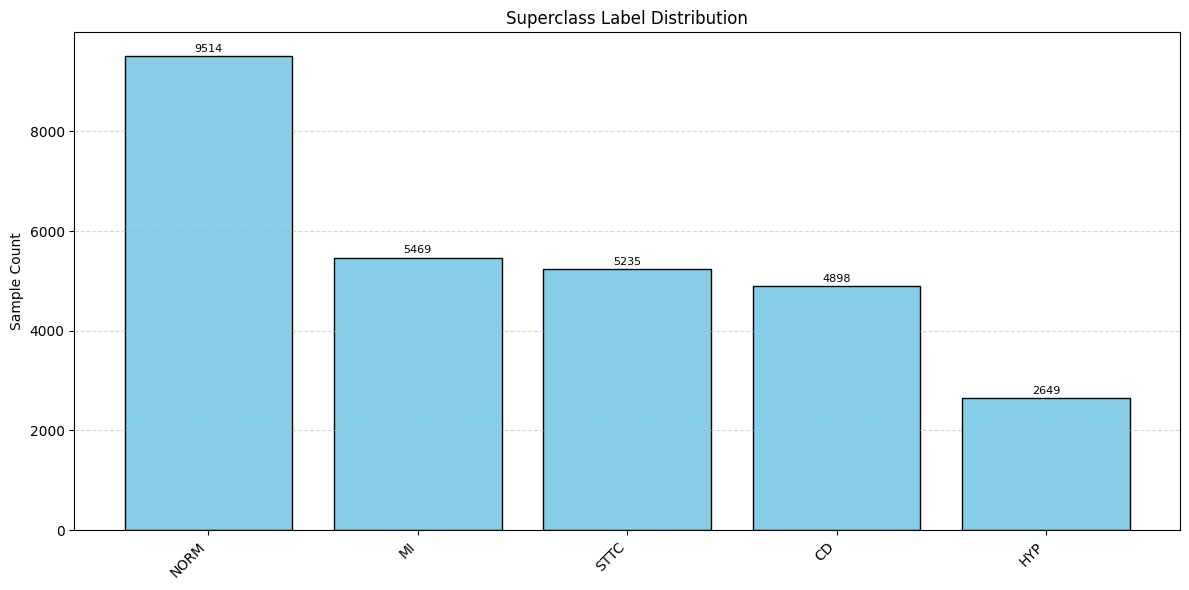

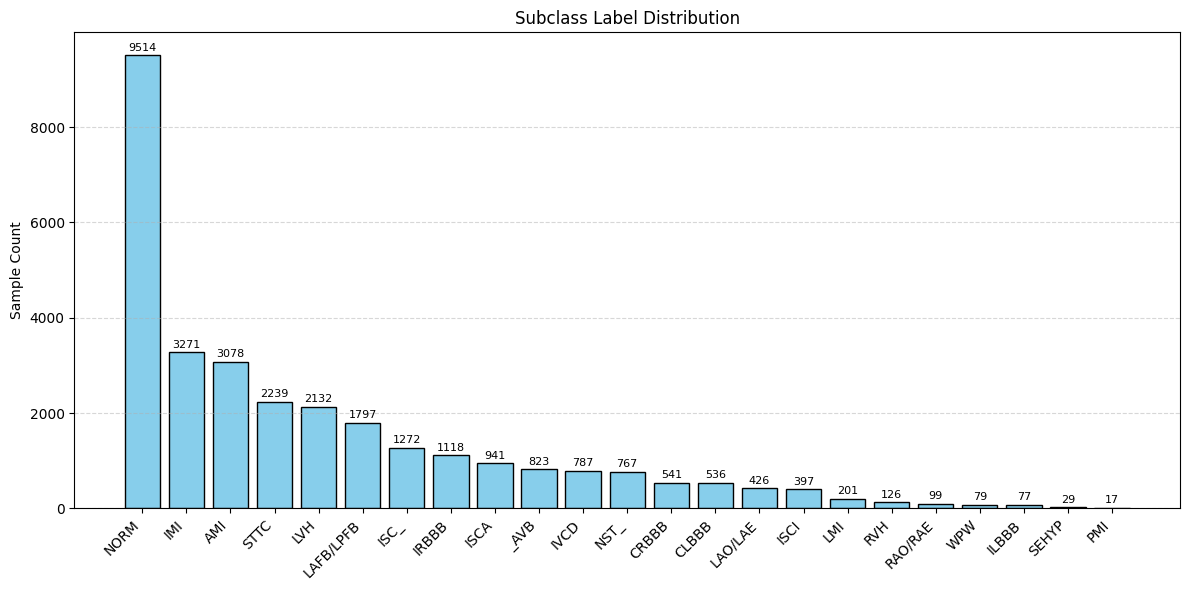

In [4]:
def load_data(df, sampling_rate, path):
    if sampling_rate == 100:
        data = [wfdb.rdsamp(path+f) for f in df.filename_lr]
    else:
        data = [wfdb.rdsamp(path+f) for f in df.filename_hr]
    #metadata = data
    data = np.array([signal for signal, meta in data])
    #return data, metadata
    return data

path = '../dataset/ptb_xl/'
sampling_rate=100

# load and convert annotation datas
Y = pd.read_csv(path+'ptbxl_database.csv', index_col='ecg_id')
Y.scp_codes = Y.scp_codes.apply(lambda x: ast.literal_eval(x))
print("Available folds:", Y.strat_fold.unique())
print("Number of folds:", len(Y.strat_fold.unique()))
# Load raw signal data
#X, metadata = load_data(Y, sampling_rate, path)
X = load_data(Y, sampling_rate, path)
# Load scp_statements.csv for diagnostic aggregation
agg_df = pd.read_csv(path+'scp_statements.csv', index_col=0)

agg_df = agg_df[agg_df.diagnostic == 1]

def aggregate_diagnostic_superclass(y_dic):
    tmp = []
    for key in y_dic.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_class)
    return list(set(tmp))

def aggregate_diagnostic_subclass(y_dic):
    tmp = []
    for key in y_dic.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_subclass)
    return list(set(tmp))
# Apply diagnostic superclass
Y['diagnostic_superclass'] = Y.scp_codes.apply(aggregate_diagnostic_superclass)
Y['diagnostic_subclass'] = Y.scp_codes.apply(aggregate_diagnostic_subclass)
# Split data into train and test
test_fold = 10
# Train
X_train = X[np.where(Y.strat_fold != test_fold)]
y_train = Y[(Y.strat_fold != test_fold)].diagnostic_superclass
y_train_sub = Y[Y.strat_fold != test_fold].diagnostic_subclass
# Test
X_test = X[np.where(Y.strat_fold == test_fold)]
y_test = Y[Y.strat_fold == test_fold].diagnostic_superclass
y_test_sub = Y[Y.strat_fold == test_fold].diagnostic_subclass

count_data = Y.diagnostic_superclass
count_data_sub = Y.diagnostic_subclass


# Superclass counts
counts = count_data.value_counts()
print("---------[Dataset] Total superclass--------")
print(counts)
logging.info("---------[Dataset] Total superclass--------")
logging.info(str(counts))

# Subclass counts
counts = count_data_sub.value_counts()
print("---------[Dataset] Total subclass--------")
print(counts)
logging.info("---------[Dataset] Total subclass--------")
logging.info(str(counts))

# Flatten all lists and count each unique label occurrence
label_counts = Counter(label for sample in count_data for label in set(sample))
print("---------[Dataset] Total per-class superclass--------")
print(label_counts)
# If using logging
logging.info("---------[Dataset] Super per-class occurrence regardless of combo--------")
logging.info(str(label_counts))

# Flatten all lists and count each unique label occurrence
label_counts_sub = Counter(label for sample in count_data_sub for label in set(sample))
print("---------[Dataset] Total per-class subclass--------")
print(label_counts_sub)
# If using logging
logging.info("---------[Dataset] Sub per-class occurrence regardless of combo--------")
logging.info(str(label_counts_sub))

def plot_distribution(counter, title):
    labels, values = zip(*sorted(counter.items(), key=lambda x: -x[1]))
    plt.figure(figsize=(12, 6))
    bars = plt.bar(labels, values, color='skyblue', edgecolor='black')
    plt.xticks(rotation=45, ha='right')
    plt.title(title)
    plt.ylabel('Sample Count')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 50, f'{height}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    plt.show()

# Plot
plot_distribution(label_counts, "Superclass Label Distribution")
plot_distribution(label_counts_sub, "Subclass Label Distribution")


del count_data, count_data_sub, label_counts, label_counts_sub
del X, Y, agg_df

In [ ]:
print("Count number of classes of y_train")
counts = y_train.value_counts()
print(counts)
logging.info("---------[Dataset] training superclass--------")
logging.info(str(counts))

Count number of classes of y_train
diagnostic_superclass
[NORM]                 8157
[MI]                   2276
[STTC]                 2158
[CD]                   1524
[MI, CD]               1164
[HYP, STTC]             708
[MI, STTC]              538
[HYP]                   479
[CD, STTC]              433
[]                      371
[NORM, CD]              362
[MI, HYP, STTC]         318
[HYP, CD]               273
[MI, CD, STTC]          202
[HYP, CD, STTC]         186
[MI, HYP]               162
[MI, HYP, CD, STTC]     138
[MI, HYP, CD]           108
[NORM, STTC]             24
[NORM, CD, STTC]          5
[HYP, MI]                 4
[HYP, CD, MI]             4
[HYP, NORM]               2
[HYP, CD, STTC, MI]       2
[HYP, STTC, MI]           2
[MI, NORM, HYP, CD]       1
Name: count, dtype: int64


In [5]:
# Flatten all lists and count each unique label occurrence
label_counts = Counter(label for sample in y_train for label in set(sample))

print(label_counts)

# If using logging
import logging
logging.info("---------[Dataset] per-class occurrence regardless of combo--------")
logging.info(str(label_counts))

Counter({'NORM': 8551, 'MI': 4919, 'STTC': 4714, 'CD': 4402, 'HYP': 2387})


In [ ]:
print("Count number of classes of y_train")
counts = y_train_sub.value_counts()
print(counts)
logging.info("---------[Dataset] training subclass--------")
logging.info(str(counts))

Count number of classes of y_train
diagnostic_subclass
[NORM]                                 912
[STTC]                                 145
[IMI]                                  139
[AMI]                                   66
[LVH]                                   48
[AMI, IMI]                              45
[LAFB/LPFB]                             45
[]                                      40
[CLBBB]                                 38
[LVH, ISC_]                             36
[IRBBB]                                 36
[NST_]                                  35
[ISCA]                                  29
[NORM, IRBBB]                           22
[LAFB/LPFB, AMI]                        21
[LVH, AMI, ISC_]                        18
[NORM, IVCD]                            17
[AMI, ISCA]                             13
[IVCD]                                  13
[CRBBB]                                 12
[LVH, IMI, ISC_]                        11
[ISCI, ISCA]                            11

In [ ]:
print("Count number of classes of y_test")
counts = y_test.value_counts()
print(counts)
logging.info("---------[Dataset] train subclass--------")
logging.info(str(counts))

Count number of classes of y_test
diagnostic_superclass
[NORM]                 912
[MI]                   256
[STTC]                 242
[CD]                   184
[CD, MI]               133
[HYP, STTC]             73
[MI, STTC]              61
[HYP]                   56
[CD, NORM]              45
[HYP, MI, STTC]         41
[]                      40
[CD, STTC]              38
[HYP, CD]               27
[HYP, CD, STTC]         25
[CD, MI, STTC]          21
[HYP, MI]               17
[HYP, CD, MI, STTC]     16
[HYP, CD, MI]            5
[NORM, STTC]             4
[HYP, CD, NORM]          2
Name: count, dtype: int64


In [6]:
# Flatten all lists and count each unique label occurrence
label_counts = Counter(label for sample in y_test for label in set(sample))

print(label_counts)

# If using logging
import logging
logging.info("---------[Dataset] Testing per-class occurrence regardless of combo--------")
logging.info(str(label_counts))

Counter({'NORM': 963, 'MI': 550, 'STTC': 521, 'CD': 496, 'HYP': 262})


In [ ]:
print("Count number of classes of y_test")
counts = y_test_sub.value_counts()
print(counts)
logging.info("---------[Dataset] test subclass--------")
logging.info(str(counts))

Count number of classes of y_test
diagnostic_subclass
[NORM]                                 912
[STTC]                                 145
[IMI]                                  139
[AMI]                                   66
[LVH]                                   48
[AMI, IMI]                              45
[LAFB/LPFB]                             45
[]                                      40
[CLBBB]                                 38
[LVH, ISC_]                             36
[IRBBB]                                 36
[NST_]                                  35
[ISCA]                                  29
[NORM, IRBBB]                           22
[LAFB/LPFB, AMI]                        21
[LVH, AMI, ISC_]                        18
[NORM, IVCD]                            17
[AMI, ISCA]                             13
[IVCD]                                  13
[CRBBB]                                 12
[LVH, IMI, ISC_]                        11
[ISCI, ISCA]                            11


In [ ]:
# Define label mapping
label_map = {'NORM': 0, 'CD': 1, 'HYP': 2, 'MI': 3, 'STTC': 4}
label_map_sub = {
 'NORM': 0, 'LAFB/LPFB': 1, 'IRBBB': 2, 'ILBBB': 3, 'CLBBB': 4,
 'CRBBB': 5, '_AVB': 6, 'IVCB': 7, 'WPW': 8, 'LVH': 9, 'RHV': 10,
 'LAO/LAE': 11, 'RAO/RAE': 12, 'SEHYP': 13, 'AMI': 14, 'IMI': 15,
 'LMI': 16, 'PMI': 17, 'ISCA': 18, 'ISCI': 19, 'ISC_': 20,
 'STTC': 21, 'NST_': 22
}

# Convert and filter


def mapping_label_and_filter_signals_np(signals: np.ndarray, labels: list, label_map: dict = label_map):
    converted_labels = []
    valid_indices = []
    
    for i, lbl_list in enumerate(labels):
        if lbl_list:  # skip empty labels
            mapped = [label_map[label] for label in lbl_list if label in label_map]
            converted_labels.append(mapped)
            valid_indices.append(i)
    
    # Use valid indices to slice the numpy signals array
    filtered_signals = signals[valid_indices, :, :]
    
    return filtered_signals, converted_labels

SyntaxError: invalid syntax (2190514542.py, line 19)

In [ ]:
X_train_, y_train_ = mapping_label_and_filter_signals_np(X_train, y_train)
y_train_ = pd.Series(y_train_)
#counts_train_label = y_train_.value_counts().sort_index()  # Sort by class label (0 → 4)
#print(counts_train_label)
X_test_, y_test_ = mapping_label_and_filter_signals_np(X_test, y_test)
y_test_ = pd.Series(y_test_)
#counts = y_test_.value_counts().sort_index()  # Sort by class label (0 → 4)
#print(counts)

def labels_to_multihot(label_list, num_classes=5):
    y = torch.zeros((len(label_list), num_classes))
    for i, labels in enumerate(label_list):
        y[i, labels] = 1
    return y

y_train_one_hot = labels_to_multihot(y_train_, num_classes=5)  # shape: (500, 5)
y_test_one_hot = labels_to_multihot(y_test_, num_classes=5)  # shape: (500, 5)

In [ ]:
x_train = torch.from_numpy(X_train_).float()  # float tensor for input
train, val, labels_train, labels_val = train_test_split(
    x_train, y_train_one_hot, test_size=0.2, random_state=42, shuffle=True
)
x_test = torch.from_numpy(X_test_).float()

batch_size = 64

train_dataset = TensorDataset(train, labels_train)
val_dataset = TensorDataset(val, labels_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

test = TensorDataset(x_test, y_test_one_hot)
test_loader = DataLoader(test, batch_size=batch_size, shuffle=False)